In [168]:
#%% Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
#plotly.express 是 Plotly 库的一个高级接口，专为快速创建各种图表而设计。
#Plotly 是一个用于制作交互式图形的库，
import seaborn as sns
import shap
#shap 是一个用于解释机器学习模型输出的 Python 库，其全称是 SHapley Additive exPlanations。
#它基于博弈论中的 Shapley 值，提供了一种统一的衡量每个特征对预测结果贡献的方法。
#shap 库能够帮助我们理解复杂模型（如深度学习、梯度提升树等）的决策过程，从而提高模型的透明性和可解释性。
import lightgbm as lgb
#lightgbm（通常简称为 lgb）是一个基于梯度提升决策树（GBDT, Gradient Boosting Decision Tree）算法
#的高效机器学习库。它由微软开发，旨在提高模型训练的速度和效率，同时保持高精度。
#LightGBM 通过引入直方图算法、叶子生长策略、直方图做差加速以及数据预排序等技术，
#实现了比其他同类库更快的训练速度和更低的内存消耗。
%matplotlib inline

from matplotlib import pyplot
from pprint import pprint
# Python 中用于美化打印（pretty-printing）的语句。
#pprint 函数来自于 pprint 模块，它提供了一种更易读的方式来输出复杂的数据结构，如字典、列表、元组等嵌套对象。
from IPython.display import display 
#Jupyter Notebook、JupyterLab 以及其他基于 IPython 的环境中非常有用的一个导入语句。
#display 函数允许你以一种更丰富和灵活的方式输出数据，
from sklearn import model_selection
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, roc_auc_score, precision_score
from sklearn.model_selection import RandomizedSearchCV

In [169]:
data_raw = pd.read_csv('./BankChurners.csv')

In [170]:
'''
从这里开始是客户的分类
'''
columns = ['Card_Category','Months_on_book','Total_Relationship_Count','Months_Inactive_12_mon','Contacts_Count_12_mon',
           'Credit_Limit','Total_Revolving_Bal','Avg_Open_To_Buy','Total_Amt_Chng_Q4_Q1','Total_Trans_Amt',
           'Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio','Attrition_Flag']

new_data = data_raw.loc[:,columns]
new_data.head()


,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag
0,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,Existing Customer
1,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,Existing Customer
2,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,Existing Customer
3,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,Existing Customer
4,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,Existing Customer


In [171]:
#数据预处理
#查看谁是分类型自变量
s = (new_data.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables in the dataset:", object_cols)


Categorical variables in the dataset: ['Card_Category', 'Attrition_Flag']


In [172]:
#对数据进行编码
LE = LabelEncoder()
for i in object_cols:
    new_data[i] = new_data[[i]].apply(LE.fit_transform)
print("All features are now numerical")
new_data.head()


All features are now numerical


,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag
0,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,1
1,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,1
2,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,1
3,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,1
4,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,1


In [213]:
#分别按照Attrition_Flag的1，0分类
# 创建一个布尔序列，表示 Attrition_Flag 为1的行（即流失的客户）
lost_customers = new_data['Attrition_Flag'] == 1
# 创建一个布尔序列，表示 Attrition_Flag 为0的行（即没有流失的客户）
retained_customers = new_data['Attrition_Flag'] == 1
# 使用布尔索引提取流失的客户数据集
data_lost = new_data[lost_customers]
# 使用布尔索引提取没有流失的客户数据集
data_retained = new_data[retained_customers]


In [214]:
#创造一个新的与流失客户data_lost相同的数据集
new_data1 = data_lost.copy()
#数据放缩
cols_del = ['Card_Category','Attrition_Flag']
new_data1 = new_data1.drop(cols_del, axis=1)


In [215]:
from sklearn.preprocessing import StandardScaler
scaler1 = StandardScaler()
scaler1.fit(new_data1)
scaled_new_data1 =  pd.DataFrame(scaler1.transform(new_data1),columns= new_data1.columns )
print("All features are now scaled")
scaled_new_data1.head()


All features are now scaled


,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0.388889,0.709949,-1.252865,0.595213,0.436364,-0.632973,0.489013,2.582952,-0.999456,-1.163844,3.870206,-0.863732
1,1.012227,1.364031,-1.252865,-0.329538,-0.051833,-0.518152,-0.008614,3.528902,-0.957606,-1.556554,13.030836,-0.702295
2,0.014887,0.055866,-1.252865,-2.179040,-0.584393,-1.658444,-0.445935,8.364270,-0.787930,-2.123802,6.974909,-1.087543
3,-0.234448,-0.598216,1.697912,-1.254289,-0.595951,1.663448,-0.734475,2.904391,-0.991770,-2.123802,6.974909,1.700918
4,-1.855126,0.709949,-1.252865,-2.179040,-0.441511,-1.658444,-0.303096,6.440225,-1.092835,-1.774727,7.707234,-1.087543


In [216]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(scaled_new_data1)
print(pca.components_)
print(pca.explained_variance_ratio_)


[[-1.08172822e-02 -2.07183985e-01 -2.22418321e-02 -2.85058491e-02
   5.12991026e-01 -1.63641444e-01  5.26483196e-01 -4.65700240e-02
   3.22846816e-01  2.73799669e-01 -4.68241341e-02 -4.52736168e-01]
 [-3.14452706e-02 -4.03393661e-01  7.76362921e-03 -1.58313859e-01
  -2.58172100e-01  1.38164056e-01 -2.69615689e-01 -7.87115131e-02
   5.27673257e-01  5.48295681e-01 -2.99493917e-02  2.58005331e-01]
 [-1.17810092e-01 -7.17818425e-02 -3.74788535e-02 -6.52649506e-02
   1.28031355e-01  2.59928146e-01  1.06320042e-01  6.61279158e-01
   6.72612520e-02 -2.00230911e-02  6.51288651e-01  1.16847414e-01]
 [ 1.08681006e-01 -2.53674848e-02 -1.75380705e-02  1.09371434e-01
   3.19249035e-01  7.51531197e-01  2.56490177e-01 -2.02997225e-01
  -1.80684496e-02 -9.17498651e-02 -2.38715780e-01  3.68553028e-01]
 [ 6.93817726e-01 -3.39239857e-02  5.89697816e-01 -3.75889472e-01
   2.11319951e-02 -9.03483130e-03  2.18790513e-02 -3.43490948e-02
  -3.44981927e-02 -3.64416836e-02  1.53505482e-01 -1.26854300e-02]
 [-3.

In [217]:
#降维并获取降维后的数据PCA_ds
pca = PCA(n_components=7)
pca.fit(scaled_new_data1)
PCA_ds = pd.DataFrame(pca.transform(scaled_new_data1), columns=(["col1","col2", "col3",'col4','col5','col6','col7']))
PCA_ds.describe().T


,count,mean,std,min,25%,50%,75%,max
col1,8500.0,-1.337492e-17,1.628031,-3.581710,-1.227832,-0.259899,0.841218,5.659548
col2,8500.0,5.349969e-17,1.412787,-4.083680,-0.964942,-0.059032,0.880272,4.698387
col3,8500.0,1.170306e-17,1.175064,-3.512536,-0.701365,-0.100866,0.548584,14.697219
col4,8500.0,-3.469120e-17,1.132264,-6.554398,-0.679848,0.115065,0.801535,3.193966
col5,8500.0,3.510917e-17,1.016005,-3.607482,-0.673027,-0.006772,0.651599,4.443887
col6,8500.0,2.006238e-17,0.995317,-3.784913,-0.683528,-0.011042,0.645347,4.766650
col7,8500.0,-2.340611e-17,0.975726,-3.471616,-0.653475,0.006159,0.669904,3.647656


In [218]:
#利用Elbow 方法来检测聚类个数
Elbow_M = KElbowVisualizer(KMeans(),k=10)
Elbow_M.fit(PCA_ds)
Elbow_M.show()


NameError: name 'KElbowVisualizer' is not defined

In [226]:
from sklearn.cluster import AgglomerativeClustering
AC = AgglomerativeClustering(n_clusters=5)
#训练模型
yhat_AC = AC.fit_predict(PCA_ds)
PCA_ds["Clusters"] = yhat_AC
data_lost["Clusters"] = yhat_AC
data_lost.head()


C:\Users\86188\AppData\Local\Temp\ipykernel_25124\2515399843.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_lost["Clusters"] = yhat_AC


,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag,Clusters
0,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,1,1
1,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,1,1
2,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,1,1
3,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,1,1
4,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,1,1


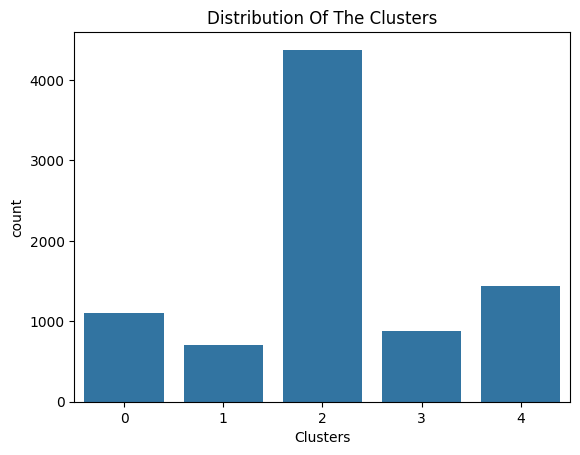

In [227]:
#模型评估
pl = sns.countplot(x=data_lost["Clusters"])
pl.set_title("Distribution Of The Clusters")
plt.show()


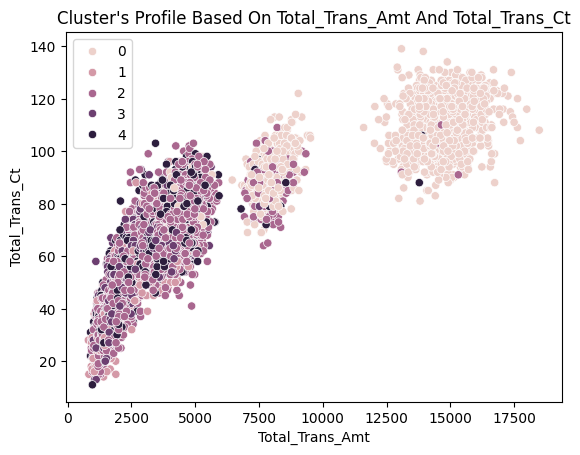

In [228]:
#模型不平衡
pl = sns.scatterplot(data = data_lost,x=data_lost["Total_Trans_Amt"], y=data_lost["Total_Trans_Ct"],hue=data_lost["Clusters"])
pl.set_title("Cluster's Profile Based On Total_Trans_Amt And Total_Trans_Ct")
plt.legend()
plt.show()


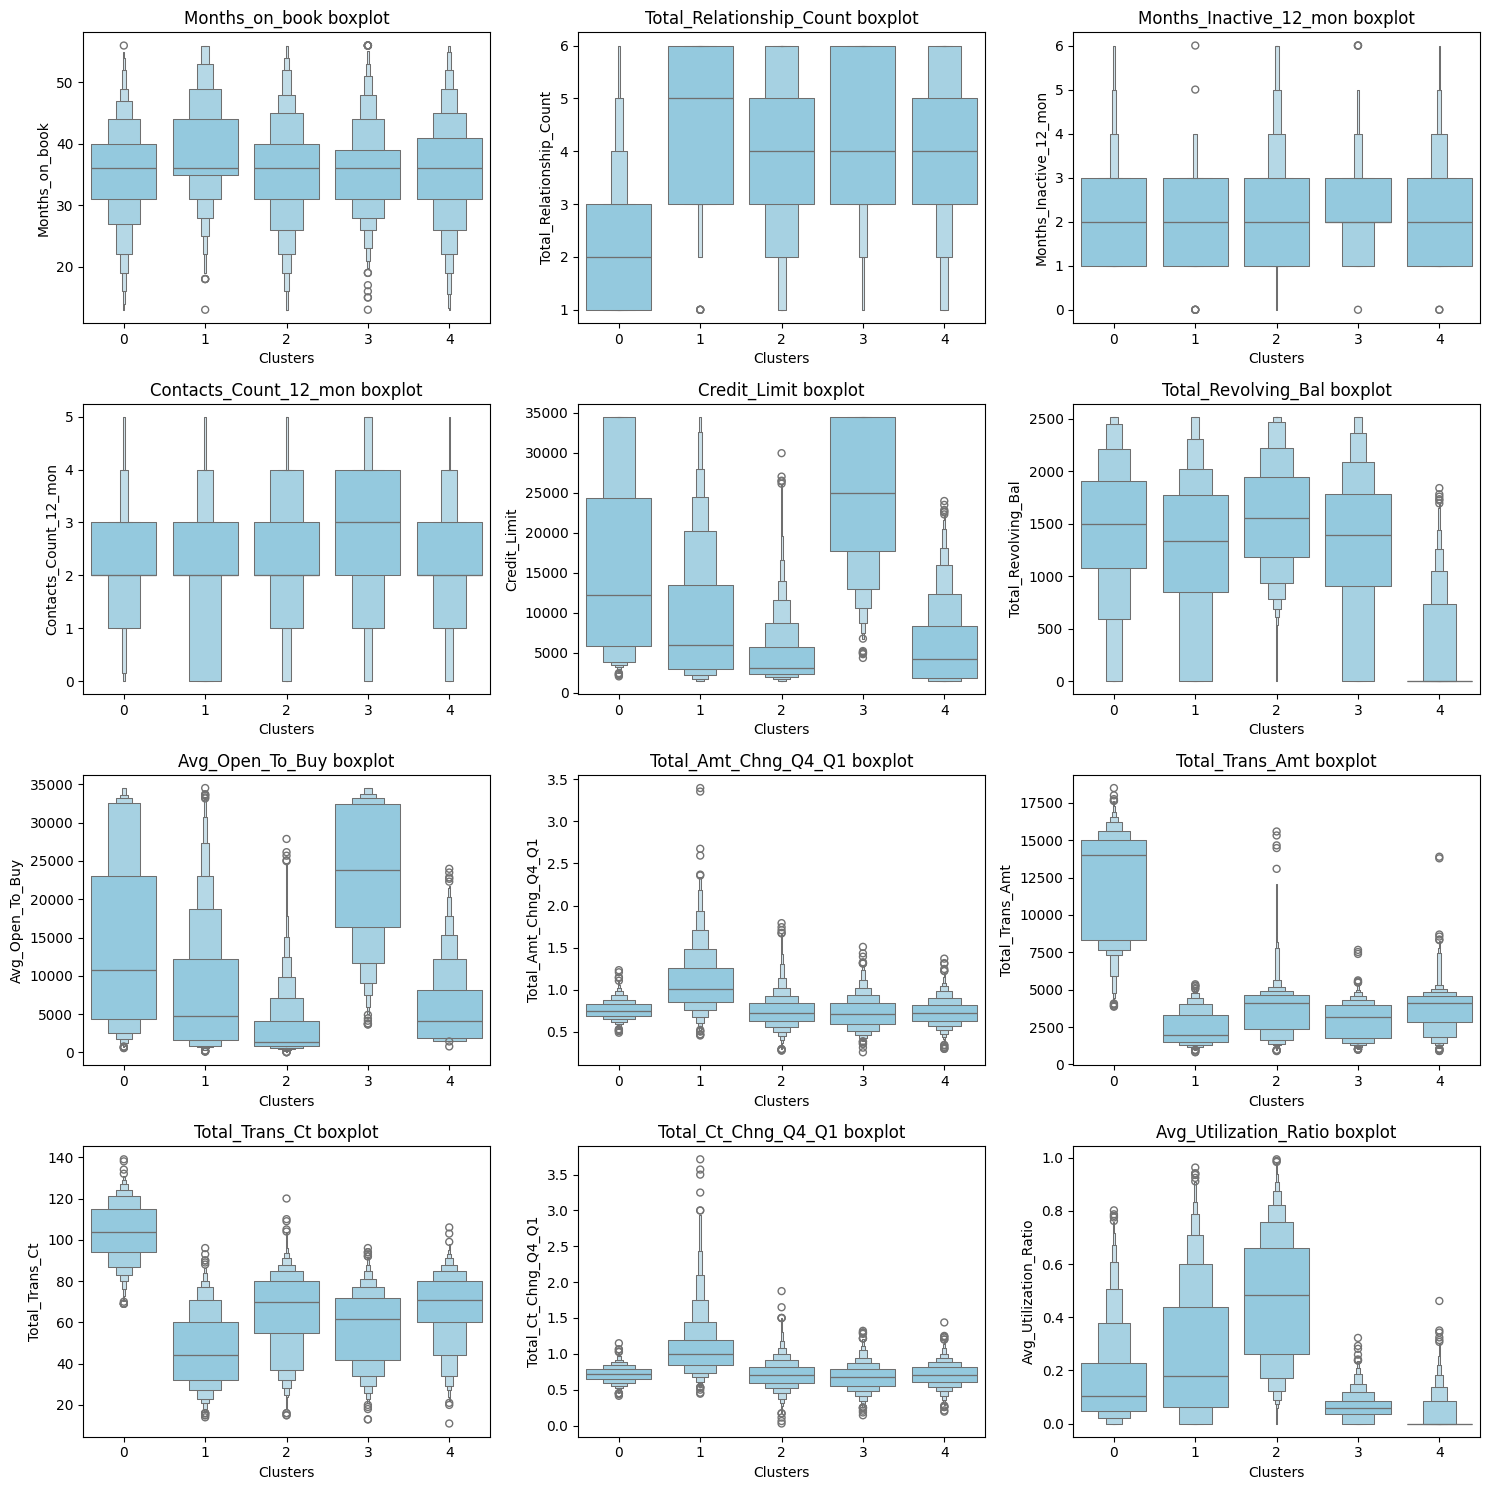

In [234]:
columns1 = ['Months_on_book','Total_Relationship_Count','Months_Inactive_12_mon','Contacts_Count_12_mon',
           'Credit_Limit','Total_Revolving_Bal','Avg_Open_To_Buy','Total_Amt_Chng_Q4_Q1','Total_Trans_Amt',
           'Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio']
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(15,15))
ax = ax.flatten()
for i , col in enumerate(columns1):
    sns.boxenplot(x=data_lost["Clusters"], y=data_lost[col] , ax = ax[i], color = "skyblue")
    ax[i].set_title(f"{col} boxplot")
plt.tight_layout()
plt.savefig(r'D:\桌面\subjects\商业数据建模\1.jpg')
plt.show()


In [230]:
columns_dims = [
           'Credit_Limit','Total_Revolving_Bal','Avg_Open_To_Buy','Total_Trans_Amt',
           'Total_Trans_Ct','Avg_Utilization_Ratio','Clusters']
# columns_dims = ['Months_on_book','Total_Relationship_Count','Months_Inactive_12_mon',
#            'Credit_Limit','Avg_Open_To_Buy','Total_Trans_Amt',
#            'Total_Trans_Ct','Avg_Utilization_Ratio','Clusters']

# columns_dims = ['Card_Category','Months_on_book','Total_Relationship_Count','Months_Inactive_12_mon','Contacts_Count_12_mon',
#            'Credit_Limit','Total_Revolving_Bal','Avg_Open_To_Buy','Total_Amt_Chng_Q4_Q1','Total_Trans_Amt',
#            'Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio','Attrition_Flag','Clusters']

data_leida_dims=data_lost[columns_dims]
data_leida_dims.head()

,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio,Clusters
0,12691.0,777,11914.0,1144,42,0.061,1
1,8256.0,864,7392.0,1291,33,0.105,1
2,3418.0,0,3418.0,1887,20,0.000,1
3,3313.0,2517,796.0,1171,20,0.760,1
4,4716.0,0,4716.0,816,28,0.000,1


In [231]:
data_dims=data_leida_dims.groupby('Clusters').mean()
data_dims.head()

,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
Clusters,,,,,,
0,15726.771611,1414.987261,14311.784349,12398.374886,103.997270,0.165370
1,9206.176096,1261.284300,7944.891796,2426.944837,46.751061,0.260146
2,4628.564397,1565.860146,3062.704250,3709.348263,65.859918,0.471987
3,24584.078767,1297.036530,23287.042237,2967.173516,57.771689,0.064289
4,5960.970596,170.546463,5790.424133,3738.945215,67.656033,0.022261


C:\Users\86188\AppData\Local\Temp\ipykernel_25124\3473345746.py:50: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(angle, value, s=30, c=colors[i], linewidths=1, zorder=10)


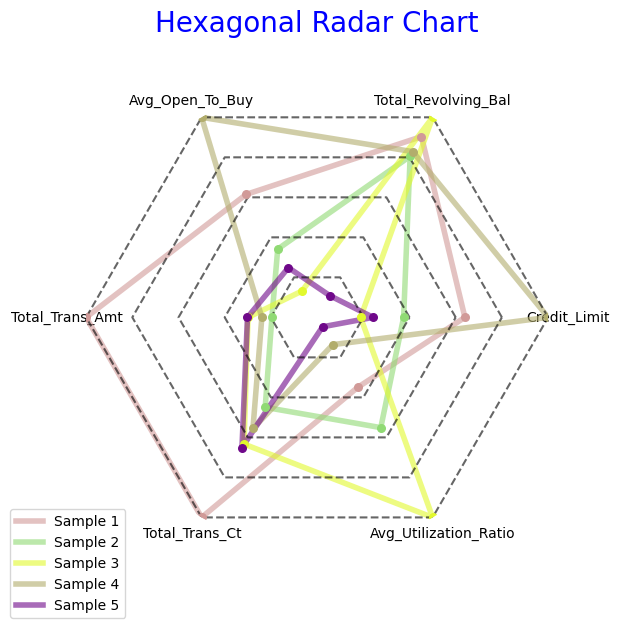

In [233]:
def plot_radar_chart(df, title="Radar Chart", figsize=(8, 6), alpha=0.6):
    """
    根据 DataFrame 的列数自动绘制多边形雷达图，最外边为多边形。
    
    参数:
    - df: pandas.DataFrame, 包含要绘制的数据，每列代表一个维度。
    - title: str, 图表标题。
    - figsize: tuple, 图表大小。
    - alpha: float, 线条透明度（这里仅用于线条）。
    """
    # 检查 DataFrame 是否为空
    if df.empty:
        print("DataFrame is empty.")
        return
    
    # 获取列名和数据
    categories = df.columns.tolist()
    num_categories = len(categories)
    
    # 如果列数少于3或多于12，给出警告（通常雷达图适合3-12个维度）
    if num_categories < 3 or num_categories > 12:
        print("Warning: Radar charts are typically best for 3 to 12 dimensions. "
              f"You have {num_categories} dimensions.")
    
    # 计算每个顶点的角度
    angles = [n / float(num_categories) * 2 * np.pi for n in range(num_categories)]
    angles += angles[:1]  # 闭合图形
    
    # 创建极坐标图
    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))
    
    # 数据归一化
    values = df.values
    normalized_values = values / values.max(axis=0)
    colors=np.random.rand(len(df.values),3)
    
    # 遍历每一行数据，绘制多个雷达图
    for i, row in enumerate(normalized_values):  # 使用归一化后的值
        row = row.flatten().tolist()
        row += row[:1]  # 闭合图形
        
        # 不再填充颜色
        # ax.fill(angles, row, color=colors[i], alpha=alpha)  # 移除此行
        
        # 绘制线条
        ax.plot(angles, row, linewidth=4, linestyle='solid', c=colors[i], alpha=alpha, label=f'Sample {i+1}')
        
        # 绘制散点
        for angle, value in zip(angles[:-1], row[:-1]):
            ax.scatter(angle, value, s=30, c=colors[i], linewidths=1, zorder=10)
    
    # 设置 x 轴标签
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    
    # 移除默认的圆形网格线
    ax.grid(False)
    
    # 移除圆形的外框
    ax.spines['polar'].set_visible(False)
    
    # 添加自定义的多边形网格线
    for r in [0.2, 0.4, 0.6, 0.8, 1.0]:
        ax.plot(angles, [r] * len(angles), 'k--', alpha=0.6)
    
    # 设置 y 轴刻度，但不显示圆形的刻度线
    ax.set_yticklabels([])  # 隐藏 y 轴刻度标签
    ax.set_ylim(0, 1)
    
    # 设置 y 轴标签的位置
    ax.set_rlabel_position(30)  # 旋转 y 轴标签以避免重叠
    
    # 添加标题
    plt.title(title, size=20, color="blue", y=1.1)
    
    # 如果样本数量不多，可以添加图例
    if len(df) <= 10:  # 假设最多显示10个样本的图例
        ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    
    # 显示图形
    plt.show()



# 绘制雷达图
plot_radar_chart(data_dims, title="Hexagonal Radar Chart")